# Estudo da correlação entre as variáveis 


In [1]:
df = pd.read_csv('Base_Consolidada.csv')
display(df)

NameError: name 'pd' is not defined

In [ ]:
#eliminando colunas 

# Suponha que seu DataFrame original seja chamado `df`
novo_df = df[['price', 'freight_value', 'payment_sequential', 'payment_installments', 'payment_value', 'review_score', 'delivery_time (days)']]
novo_df

,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,delivery_time (days)
0,58.90,13.29,1.0,2.0,72.19,5.0,7.61
1,239.90,19.93,1.0,3.0,259.83,4.0,16.22
2,199.00,17.87,1.0,5.0,216.87,5.0,7.95
3,12.99,12.79,NaN,NaN,NaN,NaN,NaN
4,199.90,18.14,1.0,3.0,218.04,5.0,25.11
...,...,...,...,...,...,...,...
112645,299.99,43.41,NaN,NaN,NaN,NaN,NaN
112646,350.00,36.53,NaN,NaN,NaN,NaN,NaN
112647,99.90,16.95,1.0,3.0,116.85,5.0,4.80
112648,55.99,8.72,1.0,3.0,64.71,5.0,1.96


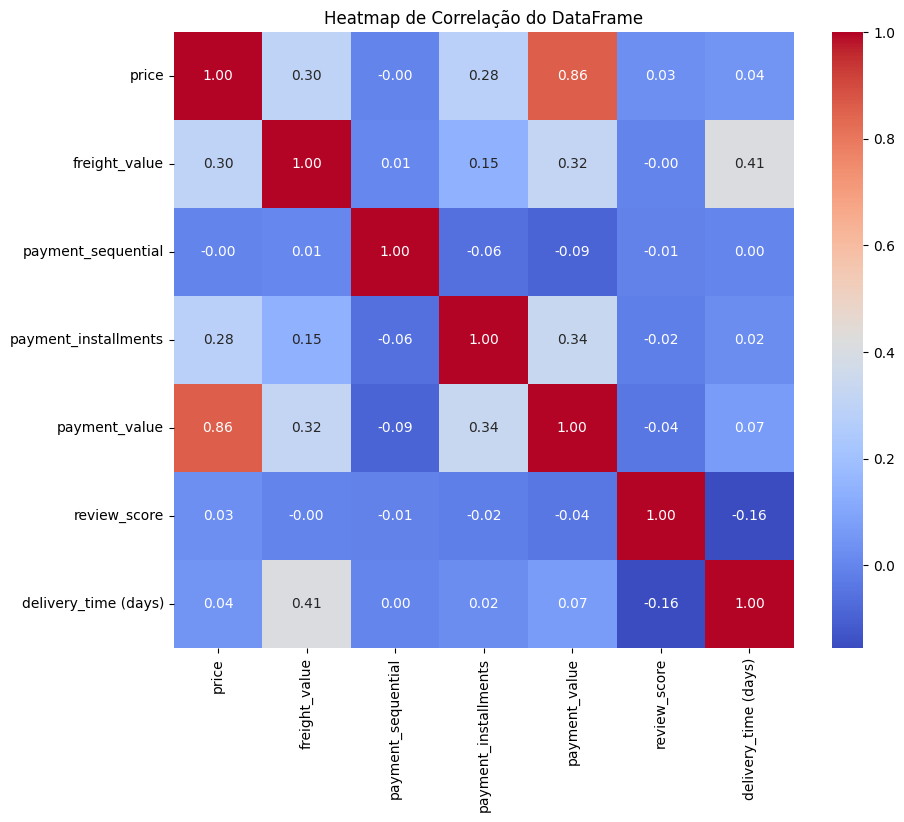

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Calculando a correlação
# Definindo uma função para remover outliers usando o método IQR
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        # Removendo valores que estão além de 1.5 vezes o IQR abaixo do Q1 ou acima do Q3
        df = df[~((df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR)))]
    return df

# Limpeza inicial, conforme descrito anteriormente
df_cleaned = novo_df.dropna(subset=['price', 'freight_value', 'payment_sequential', 'payment_installments', 'payment_value', 'review_score', 'delivery_time (days)'])
df_cleaned = df_cleaned.drop_duplicates()

# Removendo outliers das colunas numéricas
df_cleaned = remove_outliers(df_cleaned, ['price', 'freight_value', 'payment_value', 'delivery_time (days)'])

# Ajustando tipos de dados, se necessário
df_cleaned['payment_installments'] = df_cleaned['payment_installments'].astype(int)
df_cleaned['review_score'] = df_cleaned['review_score'].astype(int)
df_cleaned['payment_sequential'] = df_cleaned['payment_sequential'].astype(int)
df_cleaned['delivery_time (days)'] = df_cleaned['delivery_time (days)'].astype(int)

# Exibindo o DataFrame limpo
df_cleaned.head()


correlation_matrix = df_cleaned.corr()

# Criando o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de Correlação do DataFrame")
plt.show()

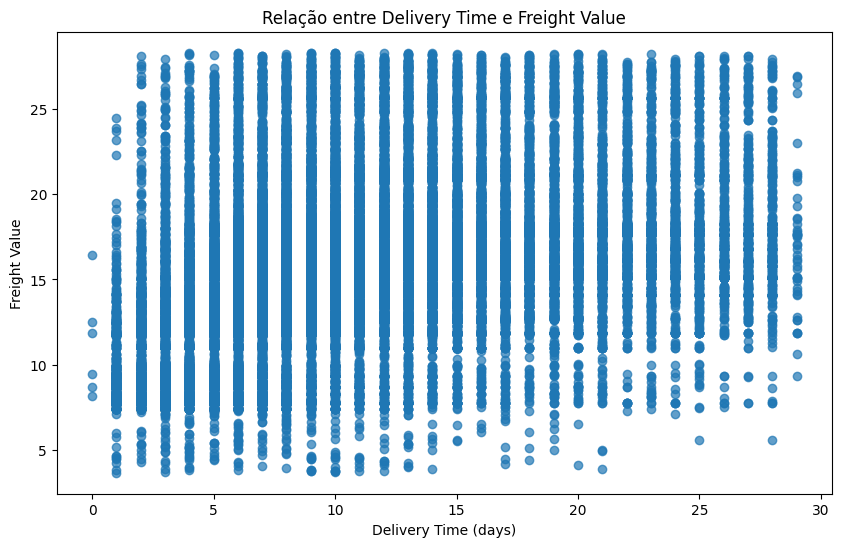

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['delivery_time (days)'], df_cleaned['freight_value'], alpha=0.7)
plt.title('Relação entre Delivery Time e Freight Value')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Freight Value')
plt.show()

#### Importando as bibliotecas necessárias 

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as plt

In [ ]:
df_category = pd.read_csv('category.csv')
df_customers = pd.read_csv('customers.csv')
df_geolocation = pd.read_csv('geolocation.csv')
df_order_items = pd.read_csv('order_items.csv')
df_order_payments = pd.read_csv('order_payments.csv')
df_order_reviews = pd.read_csv('order_reviews.csv')
df_products = pd.read_csv('products.csv')
df_sellers = pd.read_csv('sellers.csv')
df_treino = pd.read_csv('treino.csv')


In [ ]:
df_treino

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,delivery_time (days),delivery_time_model (days)
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,8.44,15.54
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,13.21,26.19
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2.87,12.11
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,16.54,22.09
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,9.99,21.45
...,...,...,...,...,...,...,...,...,...
68319,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,8.22,18.59
68320,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,22.19,23.46
68321,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,24.86,30.38
68322,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,17.09,37.11


In [ ]:
df_category


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [ ]:
df_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
df_customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,FRANCA,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,SAO BERNARDO DO CAMPO,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,SAO PAULO,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,MOGI DAS CRUZES,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,CAMPINAS,SP


In [ ]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             64440 non-null  object
 4   customer_state            49441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_nulos = df_customers[df_customers['customer_state'].isnull()]

df_nulos

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
10000,139e44006d2388e32faf1718a043675e,406a1ba5fdcd424df15806a036414d61,41760,SALVADOR,NaN
10001,d7a30a15621f7476b06e0104ffef1cfa,4fdc62ec0c92703fde661756400e686d,30130,NaN,NaN
10002,f959348f343a0d3093d076e19e59d214,f3e06e60599257ec0a10ef53641c7806,22785,NaN,NaN
10003,ecff1b1c83d0c9237a8e5fa29684a78d,edd8b65865389a453e6d20c69b046ec5,85027,NaN,NaN
10004,511bc36a7fa92687dc6fd1c5bc5e120f,3c148fda438c986c7f659079038f308e,9941,NaN,NaN
...,...,...,...,...,...
89996,c9ca9573fa99e8e7f281d4ede1c2d2ea,369cf1ff7175710f0cea99e7e9f705a0,13801,mogi mirim,NaN
89997,21357ad9c60c967f999319f084ecdc83,c12900a741b4521f3d1aad16f0217184,38408,uberlandia,NaN
89998,d8e42482d0eda51e849d77e79d749534,43707df4380a4462039aafc51636104f,2353,sao paulo,NaN
89999,fa4560374dfb90c4e50a7da55cb5bf9c,9db0703d6dd2cc17ddfa3b1d509a9464,30150,belo horizonte,NaN


In [ ]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,Sao Paulo,SP
1,1046,-23.546081,-46.644820,Sao Paulo,SP
2,1046,-23.546129,-46.642951,Sao Paulo,SP
3,1041,-23.544392,-46.639499,Sao Paulo,SP
4,1035,-23.541578,-46.641607,Sao Paulo,SP


In [ ]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                111573 non-null  float64
 6   freight_value        111574 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,NaN,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5.0,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71171 entries, 0 to 71170
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   review_id                71171 non-null  object 
 1   order_id                 71171 non-null  object 
 2   review_score             64394 non-null  float64
 3   review_comment_title     1046 non-null   object 
 4   review_comment_message   30021 non-null  object 
 5   review_creation_date     71171 non-null  object 
 6   review_answer_timestamp  71171 non-null  object 
dtypes: float64(1), object(6)
memory usage: 3.8+ MB


In [ ]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
df_order_payments.info()

# Não há valores nulos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


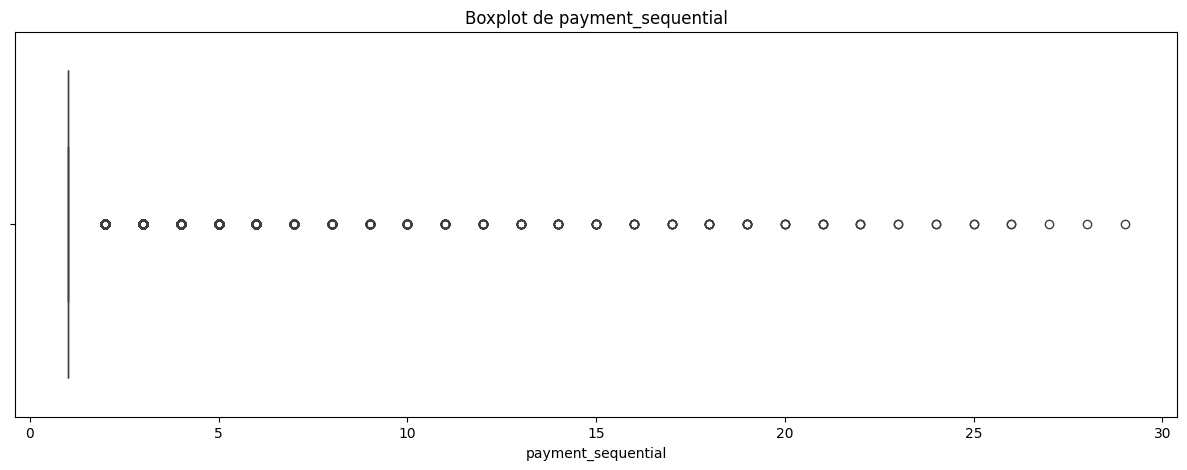

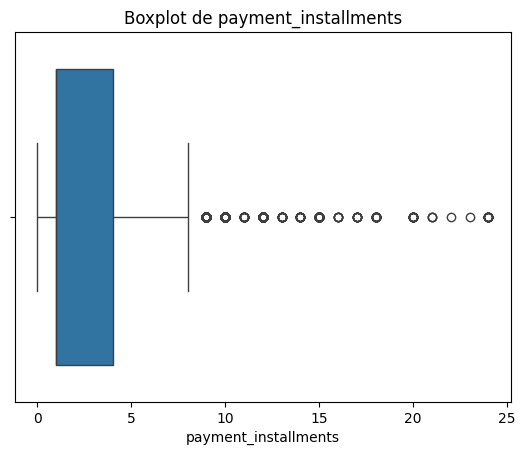

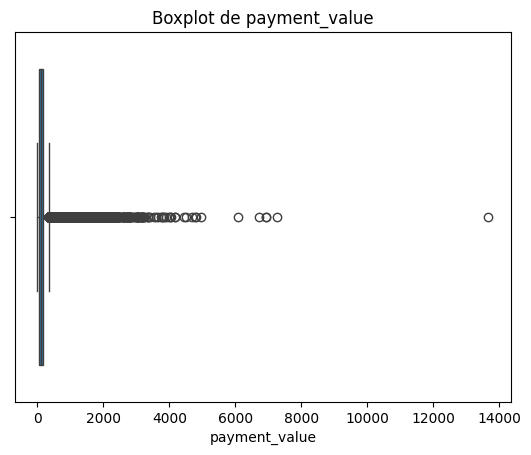

In [ ]:
plt.figure(figsize=(15, 5))

# Criar boxplots para cada coluna numérica para identificar outliers
for column in ['payment_sequential', 'payment_installments', 'payment_value']:
    sns.boxplot(x=df_order_payments[column])
    plt.title(f"Boxplot de {column}")
    plt.show()

In [ ]:
colunas_numericas = ['payment_sequential', 'payment_installments', 'payment_value']

# Dicionário para armazenar o número de outliers em cada coluna
numero_outliers = {}

# Calcular o número de outliers para cada coluna
for coluna in colunas_numericas:
    Q1 = df_order_payments[coluna].quantile(0.25)  # 25º percentil
    Q3 = df_order_payments[coluna].quantile(0.75)  # 75º percentil
    IQR = Q3 - Q1  # Intervalo interquartil
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificar os outliers
    outliers = df_order_payments[(df_order_payments[coluna] < limite_inferior) | (df_order_payments[coluna] > limite_superior)]
    
    # Contar o número de outliers
    numero_outliers[coluna] = outliers.shape[0]

# Exibir o número de outliers em cada coluna
print("Número de outliers em cada coluna:")
for coluna, count in numero_outliers.items():
    print(f"{coluna}: {count} outliers")

Número de outliers em cada coluna:
payment_sequential: 4526 outliers
payment_installments: 6313 outliers
payment_value: 7981 outliers


# Products

In [ ]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
df_products_nulos1 = df_products[df_products['product_width_cm'].isnull()]

df_products_nulos1

# Produtos sem informações dimensionais que provavelmente podemos tirar, já que são apenas 2

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_products_nulos2 = df_products[df_products['product_category_name'].isnull()]

df_products_nulos2

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [ ]:
nulos_coluna1 = df_products[df_products['product_category_name'].isnull()].index
nulos_coluna2 = df_products[df_products['product_name_lenght'].isnull()].index
nulos_coluna3 = df_products[df_products['product_description_lenght'].isnull()].index
nulos_coluna4 = df_products[df_products['product_photos_qty'].isnull()].index

# Exibir os índices com valores nulos em cada coluna
print("Índices com nulos na coluna1:", nulos_coluna1)
print("Índices com nulos na coluna2:", nulos_coluna2)
print("Índices com nulos na coluna3:", nulos_coluna3)
print("Índices com nulos na coluna4:", nulos_coluna4)

Índices com nulos na coluna1: Index([  105,   128,   145,   154,   197,   244,   294,   299,   347,   428,
       ...
       32446, 32458, 32460, 32476, 32487, 32515, 32589, 32616, 32772, 32852],
      dtype='int64', length=610)
Índices com nulos na coluna2: Index([  105,   128,   145,   154,   197,   244,   294,   299,   347,   428,
       ...
       32446, 32458, 32460, 32476, 32487, 32515, 32589, 32616, 32772, 32852],
      dtype='int64', length=610)
Índices com nulos na coluna3: Index([  105,   128,   145,   154,   197,   244,   294,   299,   347,   428,
       ...
       32446, 32458, 32460, 32476, 32487, 32515, 32589, 32616, 32772, 32852],
      dtype='int64', length=610)
Índices com nulos na coluna4: Index([  105,   128,   145,   154,   197,   244,   294,   299,   347,   428,
       ...
       32446, 32458, 32460, 32476, 32487, 32515, 32589, 32616, 32772, 32852],
      dtype='int64', length=610)


In [ ]:
if set(nulos_coluna1) == set(nulos_coluna2) == set(nulos_coluna3) == set(nulos_coluna4) :
    print("Os valores nulos nas colunas correspondem ao mesmo conjunto de produtos.")
else:
    print("Os valores nulos nas colunas não correspondem ao mesmo conjunto de produtos.")


Os valores nulos nas colunas correspondem ao mesmo conjunto de produtos.


###### Podemos achar essas informações em outra base? Não 
###### Esses valores correspondem a 1,85% da base. Eliminá-los é o melhor caminho?


In [ ]:

df_products[['product_name_lenght', 'product_description_lenght', 
                   'product_photos_qty', 'product_weight_g', 
                   'product_length_cm', 'product_height_cm', 
                   'product_width_cm']].describe()


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


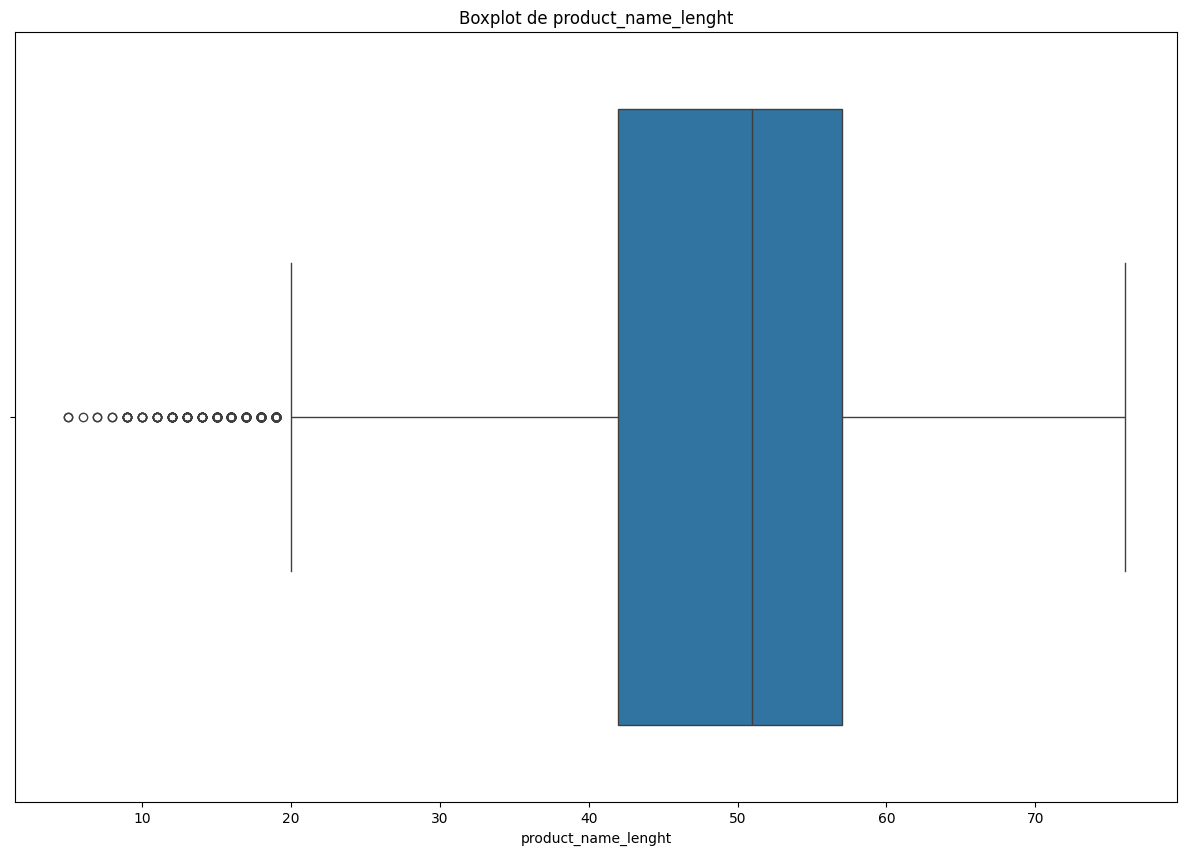

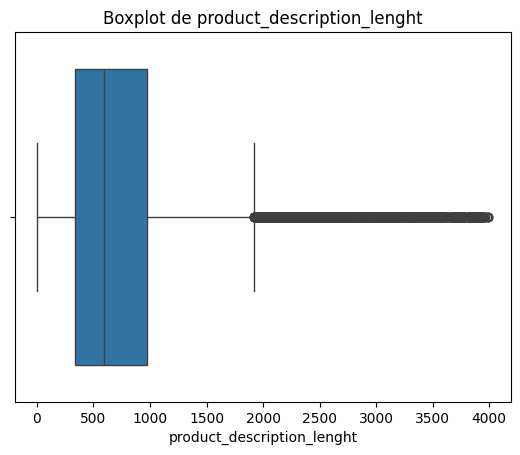

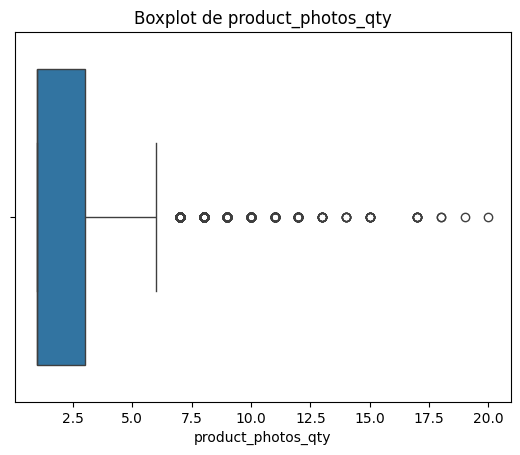

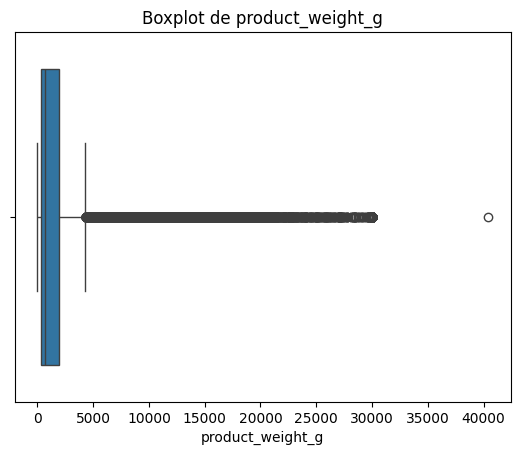

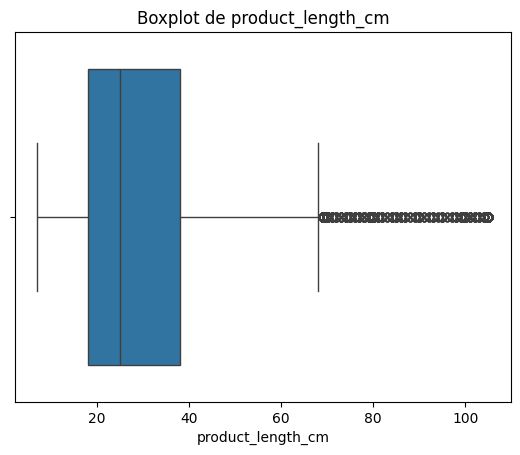

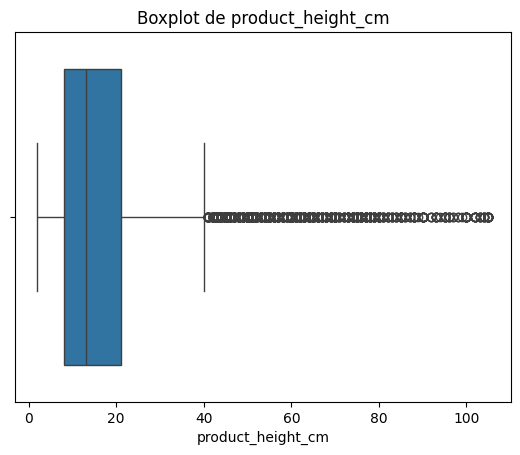

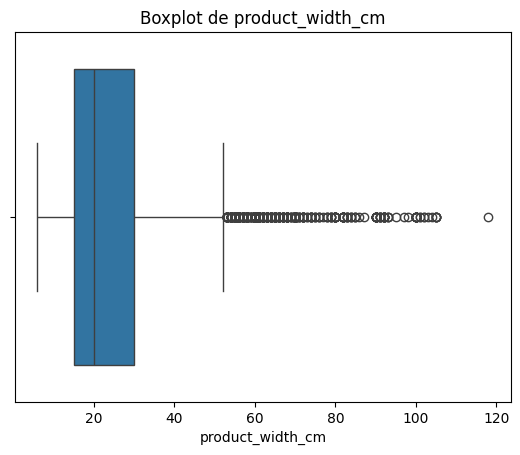

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar o tamanho da figura
plt.figure(figsize=(15, 10))

# Criar boxplots para cada coluna numérica
for column in ['product_name_lenght', 'product_description_lenght', 
               'product_photos_qty', 'product_weight_g', 
               'product_length_cm', 'product_height_cm', 
               'product_width_cm']:
    sns.boxplot(x=df_products[column])
    plt.title(f"Boxplot de {column}")
    plt.show()


In [ ]:
# Calcular IQR e limites para cada coluna numérica
for column in ['product_name_lenght', 'product_description_lenght', 
               'product_photos_qty', 'product_weight_g', 
               'product_length_cm', 'product_height_cm', 
               'product_width_cm']:
    Q1 = df_products[column].quantile(0.25)
    Q3 = df_products[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Filtrar outliers
    outliers = df_products[(df_products[column] < lower_limit) | (df_products[column] > upper_limit)]
    print(f"Outliers na coluna {column}:")
    display(outliers)
    
    # Remover outliers (opcional)
    df_products = df_products[(df_products[column] >= lower_limit) & (df_products[column] <= upper_limit)]


Outliers na coluna product_name_lenght:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


Outliers na coluna product_description_lenght:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
502,4732ecf5e4abee8f7ff4d1b8df0f7af5,automotivo,39.0,1571.0,3.0,1100.0,37.0,12.0,30.0
729,5b4341a1e617e4d33c3305158ff03c69,esporte_lazer,36.0,1581.0,1.0,150.0,18.0,7.0,14.0
809,73deb4d29b1361deb8e78b75478f210e,esporte_lazer,60.0,1596.0,3.0,750.0,30.0,11.0,20.0
1683,a4bdcbc90bfef55be462f3355d1a7d2f,telefonia,59.0,1568.0,1.0,100.0,18.0,6.0,11.0
1751,8d3995daf4103cf13ff5400bf66c1587,bebes,30.0,1570.0,3.0,300.0,30.0,10.0,20.0
...,...,...,...,...,...,...,...,...,...
30750,1f8e6a79faf4326701aa4b07c0b955e1,telefonia,53.0,1586.0,1.0,538.0,14.0,10.0,11.0
30901,f33bfcc8610360bf8b4d2831c7f4488e,beleza_saude,42.0,1576.0,1.0,425.0,22.0,14.0,18.0
31708,85bb2ec914e43df39983d98c9156ce59,relogios_presentes,39.0,1592.0,1.0,300.0,22.0,6.0,11.0
31960,dd4e0af4984c994583afeb8ac4ae7eb3,construcao_ferramentas_construcao,44.0,1593.0,1.0,200.0,16.0,16.0,16.0


Outliers na coluna product_photos_qty:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
17,a1b71017a84f92fd8da4aeefba108a24,informatica_acessorios,59.0,636.0,1.0,900.0,40.0,15.0,20.0
74,a3a03c131926ec14d4c9f3ef03016b24,pet_shop,54.0,463.0,1.0,700.0,40.0,20.0,20.0
136,65a6462e42e05ab3b8dc613566736825,malas_acessorios,49.0,540.0,4.0,1100.0,39.0,12.0,28.0
241,4fe53f6c123977ffa0dda91a2962c9e8,moveis_decoracao,51.0,1442.0,1.0,300.0,40.0,10.0,27.0
264,a1bf559ac1eab015ba992bd76d9d76c7,informatica_acessorios,32.0,1074.0,2.0,200.0,39.0,2.0,30.0
...,...,...,...,...,...,...,...,...,...
32488,2703301fe1e97e8e124a583c7664edde,moveis_decoracao,56.0,575.0,1.0,300.0,40.0,10.0,30.0
32506,891c2f4debd2ffa4848227e82c619d75,cama_mesa_banho,57.0,111.0,1.0,1150.0,40.0,15.0,30.0
32584,6e5a50058aad97da9c92bed17918bdbc,papelaria,47.0,336.0,4.0,950.0,40.0,15.0,30.0
32666,336cfb12a5468070795ae4c964f4ce47,esporte_lazer,35.0,584.0,3.0,1000.0,40.0,20.0,20.0


Outliers na coluna product_height_cm:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
2291,fb064510d22e52d7467fbf08243d2e3b,moveis_decoracao,52.0,563.0,2.0,450.0,25.0,29.0,25.0
2421,b47796afaf2c2ed23e1fe1c000ee33ac,cool_stuff,33.0,551.0,1.0,700.0,27.0,29.0,22.0
3848,bc43d9cc64d7ff9093e8dd66b4d87665,esporte_lazer,57.0,969.0,1.0,1125.0,31.0,29.0,29.0
5126,74555f75edae5066e34e251a91b8e52a,brinquedos,48.0,271.0,1.0,450.0,27.0,29.0,27.0
5248,083b8b5ce2d02b7d5d4e1ceab8b7ed04,construcao_ferramentas_jardim,53.0,685.0,1.0,1075.0,24.0,29.0,22.0
7588,44e5dd2a8bc1c55eeeffac2f3df1e8cc,beleza_saude,50.0,622.0,1.0,800.0,28.0,29.0,28.0
8883,9d4db3c01961c5e9d8a50e1c0b1fa2d1,utilidades_domesticas,35.0,868.0,1.0,1000.0,29.0,29.0,11.0
9354,f71a7c95a86564873cd996896b2976f6,informatica_acessorios,60.0,1201.0,5.0,900.0,28.0,29.0,12.0
11687,932a7e18ea9bb845420c70707362e0f7,utilidades_domesticas,43.0,513.0,2.0,200.0,28.0,29.0,19.0
11830,f17919cd5c50df5ea6b11d9665a0eb2f,esporte_lazer,44.0,951.0,1.0,1150.0,31.0,29.0,29.0


Outliers na coluna product_width_cm:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


# Sellers 

In [ ]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
df_sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [ ]:
print(df_sellers.isnull().sum())

# Não há valores nulos na base

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [ ]:
df_sellers = df_sellers.drop_duplicates()
df_sellers.info()

# Também não há duplicatas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


<Axes: xlabel='seller_zip_code_prefix'>

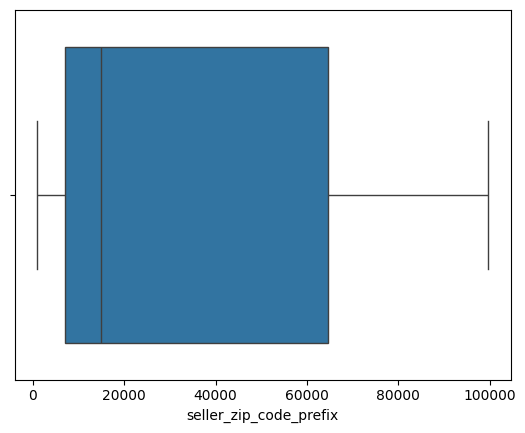

In [ ]:

sns.boxplot(x=df_sellers['seller_zip_code_prefix'])


#df = df[df['numeric_column'] < limiar]
